# Clasificación de sentimiento con una RNN — IMDB Large Movie Review Dataset

## Objetivo

Entrenar y evaluar una **Red Neuronal Recurrente (RNN)** para clasificar reseñas de películas de IMDB como:

- `0` → sentimiento **negativo**
- `1` → sentimiento **positivo**

El cuadernillo utiliza el dataset IMDB incluido en Keras y aplica un flujo completo de aprendizaje profundo: exploración, preparación de secuencias, separación correcta de datos, construcción de la RNN, regularización, callbacks, entrenamiento, métricas, curvas y análisis de errores.

### Requisitos de la práctica

El experimento cumple explícitamente:

- **Más de 20.000 ejemplos:** se usan **22.500 reseñas para entrenar**, 2.500 para validación y 25.000 para prueba.
- **Longitud de secuencia `n > 20`:** cada entrada se transforma a **300 tokens** (`MAXLEN = 300`).
- Modelo recurrente principal: **`SimpleRNN`**.
- Tarea: **clasificación binaria de sentimiento**.

> El conjunto oficial de prueba se mantiene completamente separado durante el entrenamiento y el ajuste del umbral.

## Fuentes oficiales

- Keras IMDB dataset: https://keras.io/api/datasets/imdb/
- Ejemplo oficial de Keras con IMDB y secuencias: https://keras.io/examples/nlp/bidirectional_lstm_imdb/
- Keras SimpleRNN: https://keras.io/api/layers/recurrent_layers/simple_rnn/
- Keras callbacks: https://keras.io/api/callbacks/

## 1. Dependencias

El cuadernillo usa:

- **TensorFlow / Keras**: red neuronal, dataset y entrenamiento.
- **NumPy**: operaciones numéricas.
- **Pandas**: tablas de resultados.
- **Matplotlib**: visualizaciones.
- **scikit-learn**: partición estratificada y métricas adicionales.

Si falta alguna dependencia, descomenta y ejecuta la siguiente celda.

In [1]:
# %pip install -q tensorflow scikit-learn matplotlib pandas

## 2. Importaciones, reproducibilidad y hardware

In [2]:
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    precision_recall_curve,
)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__ if hasattr(keras, "__version__") else "integrado en TensorFlow")

TensorFlow: 2.21.0
Keras: 3.15.1


In [3]:
# Semillas para hacer los resultados lo más reproducibles posible.
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices("GPU")

print("GPU detectada:" if gpus else "GPU no detectada; se utilizará CPU.")
for gpu in gpus:
    print(" -", gpu)

GPU no detectada; se utilizará CPU.


## 3. Configuración del experimento

Los hiperparámetros se centralizan para facilitar experimentos posteriores.

### Decisiones principales

- `NUM_WORDS = 20_000`: conservamos las 20.000 palabras más frecuentes.
- `MAXLEN = 300`: cada reseña tendrá exactamente 300 posiciones.
- `EMBEDDING_DIM = 128`: cada token se representa mediante un vector aprendido de 128 valores.
- `RNN_UNITS = 64`: número de unidades recurrentes.
- `BATCH_SIZE = 128`: buen equilibrio entre memoria y velocidad para este dataset.
- `EPOCHS = 20`: es un máximo; `EarlyStopping` puede terminar antes.

In [4]:
NUM_WORDS = 20_000
MAXLEN = 300

EMBEDDING_DIM = 128
RNN_UNITS = 64

BATCH_SIZE = 128
EPOCHS = 20
LEARNING_RATE = 1e-3

VALIDATION_SIZE = 2_500

CHECKPOINT_PATH = Path("mejor_rnn_imdb.keras")
FINAL_MODEL_PATH = Path("rnn_imdb_final.keras")
HISTORY_PATH = Path("historial_rnn_imdb.csv")

assert MAXLEN > 20, "La longitud de secuencia debe ser mayor a 20."

## 4. Carga del dataset IMDB

`keras.datasets.imdb.load_data()` devuelve las reseñas ya convertidas a **secuencias de índices enteros**.

Keras proporciona:

- 25.000 reseñas oficiales de entrenamiento.
- 25.000 reseñas oficiales de prueba.

Cada entero representa una palabra del vocabulario. El valor `0` se reserva para padding.

In [5]:
(x_train_full, y_train_full), (x_test_raw, y_test) = keras.datasets.imdb.load_data(
    num_words=NUM_WORDS,
    seed=SEED,
)

x_train_full = np.asarray(x_train_full, dtype=object)
x_test_raw = np.asarray(x_test_raw, dtype=object)
y_train_full = np.asarray(y_train_full, dtype=np.int32)
y_test = np.asarray(y_test, dtype=np.int32)

print("Reseñas del conjunto oficial de entrenamiento:", len(x_train_full))
print("Reseñas del conjunto oficial de prueba:", len(x_test_raw))
print("Total de ejemplos etiquetados:", len(x_train_full) + len(x_test_raw))

assert len(x_train_full) == 25_000
assert len(x_test_raw) == 25_000
assert len(x_train_full) + len(x_test_raw) > 20_000

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


c:\Users\josia\miniforge3\envs\ds_env\Lib\site-packages\keras\src\datasets\npz_utils.py:68: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return RestrictedUnpickler(fp).load()


Reseñas del conjunto oficial de entrenamiento: 25000
Reseñas del conjunto oficial de prueba: 25000
Total de ejemplos etiquetados: 50000


## 5. Exploración inicial de los datos

In [6]:
longitudes_train = np.array([len(review) for review in x_train_full])
longitudes_test = np.array([len(review) for review in x_test_raw])

estadisticas_longitud = pd.DataFrame(
    {
        "train": pd.Series(longitudes_train).describe(),
        "test": pd.Series(longitudes_test).describe(),
    }
)

estadisticas_longitud

,train,test
count,25000.000000,25000.000000
mean,238.713640,230.804200
std,176.497204,169.164471
min,11.000000,7.000000
25%,130.000000,128.000000
50%,178.000000,174.000000
75%,291.000000,280.000000
max,2494.000000,2315.000000


In [7]:
print(f"Longitud mínima (train): {longitudes_train.min()}")
print(f"Longitud mediana (train): {np.median(longitudes_train):.0f}")
print(f"Longitud media (train): {longitudes_train.mean():.1f}")
print(f"Longitud máxima (train): {longitudes_train.max()}")
print(f"Porcentaje con más de {MAXLEN} tokens: {(longitudes_train > MAXLEN).mean() * 100:.2f}%")

Longitud mínima (train): 11
Longitud mediana (train): 178
Longitud media (train): 238.7
Longitud máxima (train): 2494
Porcentaje con más de 300 tokens: 23.63%


### 5.1 Distribución de clases

In [8]:
balance = pd.DataFrame(
    {
        "clase": ["Negativa (0)", "Positiva (1)"],
        "train": [
            int(np.sum(y_train_full == 0)),
            int(np.sum(y_train_full == 1)),
        ],
        "test": [
            int(np.sum(y_test == 0)),
            int(np.sum(y_test == 1)),
        ],
    }
)

balance

,clase,train,test
0,Negativa (0),12500,12500
1,Positiva (1),12500,12500


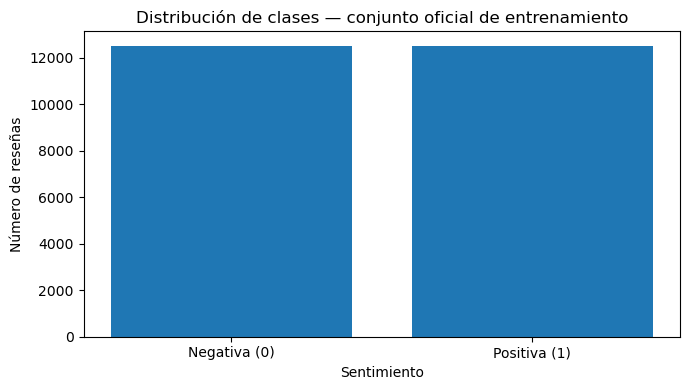

In [9]:
plt.figure(figsize=(7, 4))
plt.bar(balance["clase"], balance["train"])
plt.title("Distribución de clases — conjunto oficial de entrenamiento")
plt.ylabel("Número de reseñas")
plt.xlabel("Sentimiento")
plt.tight_layout()
plt.show()

### 5.2 Distribución de la longitud de las reseñas

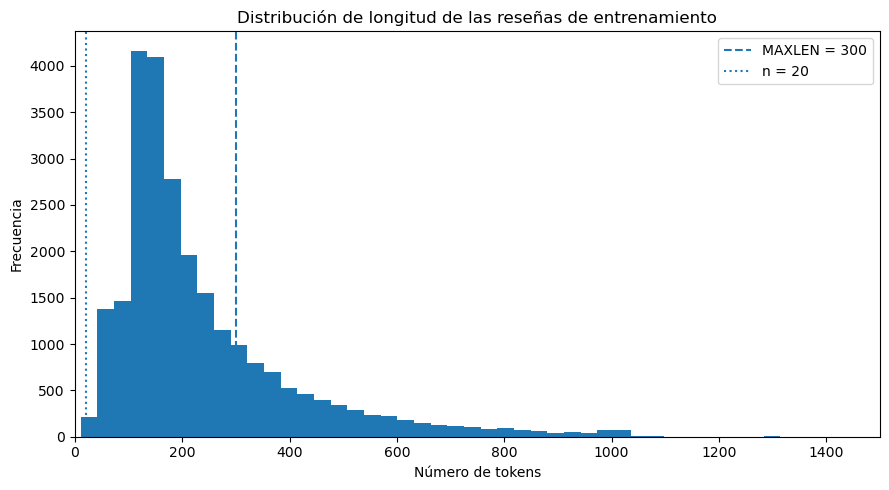

In [10]:
plt.figure(figsize=(9, 5))
plt.hist(longitudes_train, bins=80)
plt.axvline(MAXLEN, linestyle="--", label=f"MAXLEN = {MAXLEN}")
plt.axvline(20, linestyle=":", label="n = 20")
plt.xlim(0, min(1500, int(longitudes_train.max())))
plt.title("Distribución de longitud de las reseñas de entrenamiento")
plt.xlabel("Número de tokens")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Decodificar una reseña

Esta sección no es necesaria para entrenar el modelo, pero ayuda a comprender qué contienen las secuencias numéricas.

In [11]:
word_index = keras.datasets.imdb.get_word_index()

# Keras reserva:
# 0 = PAD
# 1 = START
# 2 = OOV (out-of-vocabulary)
# Los índices reales de palabras se desplazan +3.
reverse_word_index = {index + 3: word for word, index in word_index.items()}
reverse_word_index[0] = "[PAD]"
reverse_word_index[1] = "[START]"
reverse_word_index[2] = "[OOV]"


def decodificar_reseña(sequence, incluir_especiales=False):
    tokens = []

    for token_id in sequence:
        token_id = int(token_id)

        if not incluir_especiales and token_id in {0, 1}:
            continue

        tokens.append(reverse_word_index.get(token_id, "[OOV]"))

    return " ".join(tokens)


indice = 0

print("Etiqueta:", "Positiva" if y_train_full[indice] == 1 else "Negativa")
print()
print(decodificar_reseña(x_train_full[indice])[:1500])

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
Etiqueta: Positiva

in panic in the streets richard widmark plays u s navy doctor who has his week [OOV] interrupted with a corpse that contains plague as cop paul douglas properly points out the guy died from two bullets in the chest that's not the issue here the two of them become unwilling partners in an effort to find the killers and anyone else exposed to the disease br br as was pointed out by any number of people for some reason director elia kazan did not bother to cast the small parts with anyone that sounds like they're from louisiana having been to new orleans where the story takes place i can personally [OOV] to that richard widmark and his wife barbara bel geddes can be excused because as a navy doctor he could be assigned there but for those that are natives it doesn't work br br but with plague out there and the news being kept a secret the new orleans [OOV] starts a [OOV] of the city's underworld the dead guy came off a s

## 7. División entrenamiento / validación

No usaremos el conjunto oficial de prueba para tomar decisiones de entrenamiento.

De las 25.000 reseñas oficiales de entrenamiento:

- **22.500 → entrenamiento**
- **2.500 → validación**

La división es **estratificada**, por lo que mantiene aproximadamente la misma proporción de reseñas positivas y negativas.

Esto deja **22.500 ejemplos utilizados realmente para entrenar**, cumpliendo el requisito de más de 20.000.

In [12]:
x_train_raw, x_val_raw, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=VALIDATION_SIZE,
    random_state=SEED,
    stratify=y_train_full,
)

print("Entrenamiento:", len(x_train_raw))
print("Validación:", len(x_val_raw))
print("Prueba:", len(x_test_raw))

assert len(x_train_raw) == 22_500
assert len(x_train_raw) > 20_000
assert len(x_val_raw) == 2_500
assert len(x_test_raw) == 25_000

Entrenamiento: 22500
Validación: 2500
Prueba: 25000


In [13]:
def proporciones_clase(y):
    values, counts = np.unique(y, return_counts=True)
    return {int(v): float(c / len(y)) for v, c in zip(values, counts)}


print("Train:", proporciones_clase(y_train))
print("Val:  ", proporciones_clase(y_val))
print("Test: ", proporciones_clase(y_test))

Train: {0: 0.5, 1: 0.5}
Val:   {0: 0.5, 1: 0.5}
Test:  {0: 0.5, 1: 0.5}


## 8. Padding y truncamiento

Una RNN procesa secuencias con un número de pasos temporales.

Las reseñas tienen longitudes distintas, así que las convertimos a:

\[
X \in \mathbb{N}^{m \times 300}
\]

donde:

- `m` = número de reseñas.
- `300` = número de tokens por reseña.

Usamos:

- `padding="post"`: los ceros se agregan al final.
- `truncating="post"`: si una reseña supera 300 tokens, conservamos sus primeros 300.
- `mask_zero=True` en la capa `Embedding`: el modelo ignora las posiciones de padding.

In [14]:
def preparar_secuencias(sequences):
    return keras.utils.pad_sequences(
        sequences,
        maxlen=MAXLEN,
        padding="post",
        truncating="post",
        value=0,
    ).astype("int32")


x_train = preparar_secuencias(x_train_raw)
x_val = preparar_secuencias(x_val_raw)
x_test = preparar_secuencias(x_test_raw)

print("x_train:", x_train.shape)
print("x_val:  ", x_val.shape)
print("x_test: ", x_test.shape)

assert x_train.shape == (22_500, MAXLEN)
assert x_val.shape == (2_500, MAXLEN)
assert x_test.shape == (25_000, MAXLEN)
assert x_train.shape[1] > 20

x_train: (22500, 300)
x_val:   (2500, 300)
x_test:  (25000, 300)


In [15]:
# Inspección de una secuencia después del padding.
print("Primeros 40 tokens:")
print(x_train[0][:40])

print("\nÚltimos 20 tokens:")
print(x_train[0][-20:])

print("\nCantidad de tokens distintos de padding:",
      int(np.count_nonzero(x_train[0])))

Primeros 40 tokens:
[    1    60   197   146    24     4  1126     7  6422   451    14    20
    16    41 12971  3603  2482    50    71   196  2881   499   302     5
  9692     7  1224  4019  1757  1937     5  2772     2   725     4  2824
   141     6    22     6]

Últimos 20 tokens:
[  10   14   16   11   38  111  771   35 1210  298   20   45   44  119
    8   30  252   21   45   82]

Cantidad de tokens distintos de padding: 300


## 9. Construcción eficiente del pipeline con `tf.data`

Buenas prácticas aplicadas:

- Solo se hace `shuffle` sobre entrenamiento.
- Validación y prueba mantienen un orden estable.
- `batch()` procesa múltiples reseñas simultáneamente.
- `prefetch(tf.data.AUTOTUNE)` permite preparar el siguiente batch mientras el modelo entrena.

In [16]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    tf.data.Dataset.from_tensor_slices((x_train, y_train))
    .shuffle(buffer_size=len(x_train), seed=SEED, reshuffle_each_iteration=True)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((x_val, y_val))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((x_test, y_test))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 300), dtype=tf.int32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

## 10. Arquitectura de la RNN

Flujo del modelo:

```text
300 índices de palabras
        ↓
Embedding(20.000 → 128)
        ↓
SpatialDropout1D
        ↓
SimpleRNN(64)
        ↓
Dense(32, ReLU)
        ↓
Dropout
        ↓
Dense(1, Sigmoid)
        ↓
P(sentimiento positivo)
```

### ¿Por qué una capa `Embedding`?

Los enteros de entrada son **identificadores**, no valores numéricos continuos. La capa `Embedding` aprende una representación vectorial para cada palabra.

### ¿Por qué `SimpleRNN`?

Es la forma más directa de estudiar una RNN clásica. Mantiene un estado oculto que se actualiza mientras lee los tokens de izquierda a derecha.

### Regularización

- `SpatialDropout1D`: apaga dimensiones completas del embedding durante entrenamiento.
- `Dropout`: reduce coadaptación en la cabeza de clasificación.
- `clipnorm=1.0`: limita la norma del gradiente y ayuda frente a gradientes explosivos.

In [17]:
def construir_modelo():
    inputs = keras.Input(shape=(MAXLEN,), dtype="int32", name="tokens")

    x = layers.Embedding(
        input_dim=NUM_WORDS,
        output_dim=EMBEDDING_DIM,
        mask_zero=True,
        name="embedding",
    )(inputs)

    x = layers.SpatialDropout1D(0.20, name="spatial_dropout")(x)

    x = layers.SimpleRNN(
        RNN_UNITS,
        activation="tanh",
        return_sequences=False,
        name="simple_rnn",
    )(x)

    x = layers.Dense(32, activation="relu", name="dense")(x)
    x = layers.Dropout(0.40, name="dropout")(x)

    outputs = layers.Dense(1, activation="sigmoid", name="sentimiento")(x)

    return keras.Model(inputs=inputs, outputs=outputs, name="RNN_IMDB")


model = construir_modelo()
model.summary()

Model: "RNN_IMDB"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tokens (InputLayer) │ (None, 300)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 300, 128)  │  2,560,000 │ tokens[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout     │ (None, 300, 128)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 300)       │          0 │ tokens[0][0]      │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 64)        │     12,352 │ spatial_dropout[… │
│ (SimpleRNN)         │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      2,080 │ simple_rnn[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sentimiento (Dense) │ (None, 1)         │         33 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,574,465 (9.82 MB)

 Trainable params: 2,574,465 (9.82 MB)

 Non-trainable params: 0 (0.00 B)

## 11. Compilación y métricas

Como es clasificación binaria:

- **Loss:** `BinaryCrossentropy`
- **Activación de salida:** `sigmoid`

Métricas monitorizadas durante el entrenamiento:

- `accuracy`
- `precision`
- `recall`
- `roc_auc`
- `pr_auc`

Además, al final calcularemos **F1-score**, matriz de confusión, curva ROC y curva Precision–Recall.

In [18]:
optimizer = keras.optimizers.Adam(
    learning_rate=LEARNING_RATE,
    clipnorm=1.0,
)

model.compile(
    optimizer=optimizer,
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="roc_auc", curve="ROC"),
        keras.metrics.AUC(name="pr_auc", curve="PR"),
    ],
)

## 12. Callbacks

Se incorporan tres mecanismos importantes:

1. **EarlyStopping**  
   Detiene el entrenamiento si `val_loss` deja de mejorar y restaura los mejores pesos.

2. **ReduceLROnPlateau**  
   Reduce el learning rate cuando la validación se estanca.

3. **ModelCheckpoint**  
   Guarda automáticamente el mejor modelo observado según `val_loss`.

También usamos `CSVLogger` para conservar el historial de cada época.

In [19]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=3,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=1,
        min_delta=1e-4,
        min_lr=1e-6,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.CSVLogger(
        filename=HISTORY_PATH,
        append=False,
    ),
    keras.callbacks.TerminateOnNaN(),
]

## 13. Entrenamiento

El máximo es de 20 épocas, pero `EarlyStopping` puede finalizar antes si el modelo deja de mejorar en validación.

> Una `SimpleRNN` procesa los pasos de una secuencia de forma recurrente, por lo que puede ser considerablemente más lenta que una red densa y, en secuencias largas, también más difícil de entrenar que GRU/LSTM.

In [20]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/20


c:\Users\josia\miniforge3\envs\ds_env\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.6039 - loss: 0.6480 - pr_auc: 0.6587 - precision: 0.6016 - recall: 0.6155 - roc_auc: 0.6573
Epoch 1: val_loss improved from None to 0.46691, saving model to mejor_rnn_imdb.keras

Epoch 1: finished saving model to mejor_rnn_imdb.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 33s 160ms/step - accuracy: 0.6039 - loss: 0.6480 - pr_auc: 0.6587 - precision: 0.6016 - recall: 0.6155 - roc_auc: 0.6573 - val_accuracy: 0.7880 - val_loss: 0.4669 - val_pr_auc: 0.8690 - val_precision: 0.8175 - val_recall: 0.7416 - val_roc_auc: 0.8631 - learning_rate: 0.0010
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.8188 - loss: 0.4255 - pr_auc: 0.8807 - precision: 0.8241 - recall: 0.8108 - roc_auc: 0.8856
Epoch 2: val_loss improved from 0.46691 to 0.37787, saving model to mejor_rnn_imdb.keras

Epoch 2: finished saving model to mejor_rnn_imdb.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 31s 103ms/step - accuracy: 0.8188 - loss: 0.4255 - pr_auc: 0.8807 - pre

## 14. Curvas de entrenamiento

In [21]:
history_df = pd.DataFrame(history.history)
history_df.index = np.arange(1, len(history_df) + 1)
history_df.index.name = "epoch"

history_df

,accuracy,loss,pr_auc,precision,recall,roc_auc,val_accuracy,val_loss,val_pr_auc,val_precision,val_recall,val_roc_auc,learning_rate
epoch,,,,,,,,,,,,,
1,0.603911,0.648017,0.658668,0.601564,0.615467,0.657281,0.7880,0.466910,0.868999,0.817460,0.7416,0.863136,0.00100
2,0.818844,0.425467,0.880717,0.824087,0.810756,0.885627,0.8436,0.377874,0.912711,0.837923,0.8520,0.911409,0.00100
3,0.887333,0.290552,0.946245,0.886406,0.888533,0.947588,0.8104,0.425972,0.888952,0.799383,0.8288,0.889304,0.00100
4,0.948533,0.148332,0.984662,0.946391,0.950933,0.985741,0.8484,0.464661,0.902833,0.855510,0.8384,0.908682,0.00050
5,0.979822,0.066562,0.997034,0.980335,0.979289,0.997031,0.8448,0.542961,0.889180,0.850407,0.8368,0.901189,0.00025


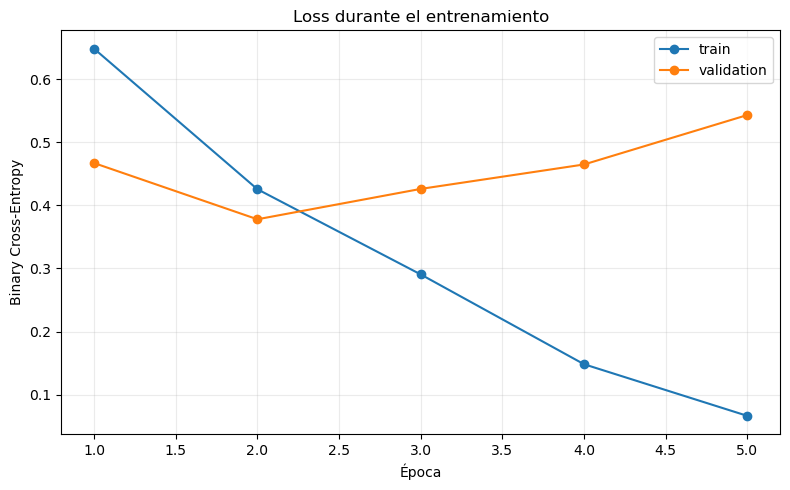

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(history_df.index, history_df["loss"], marker="o", label="train")
plt.plot(history_df.index, history_df["val_loss"], marker="o", label="validation")
plt.title("Loss durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Binary Cross-Entropy")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

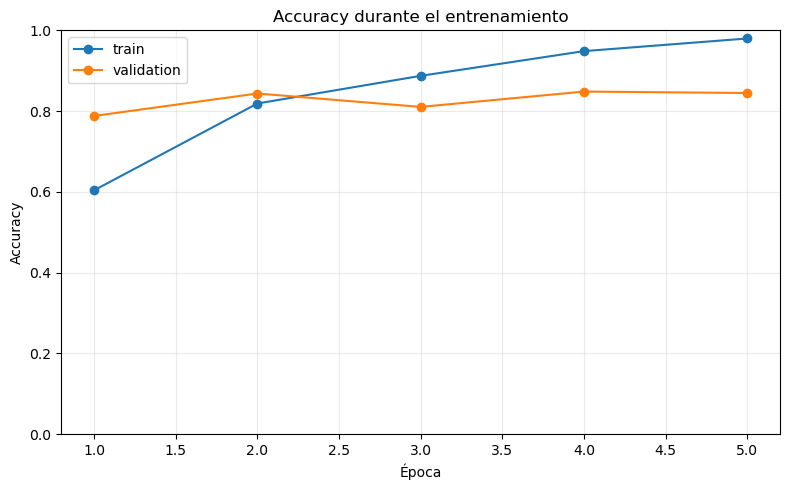

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(history_df.index, history_df["accuracy"], marker="o", label="train")
plt.plot(history_df.index, history_df["val_accuracy"], marker="o", label="validation")
plt.title("Accuracy durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

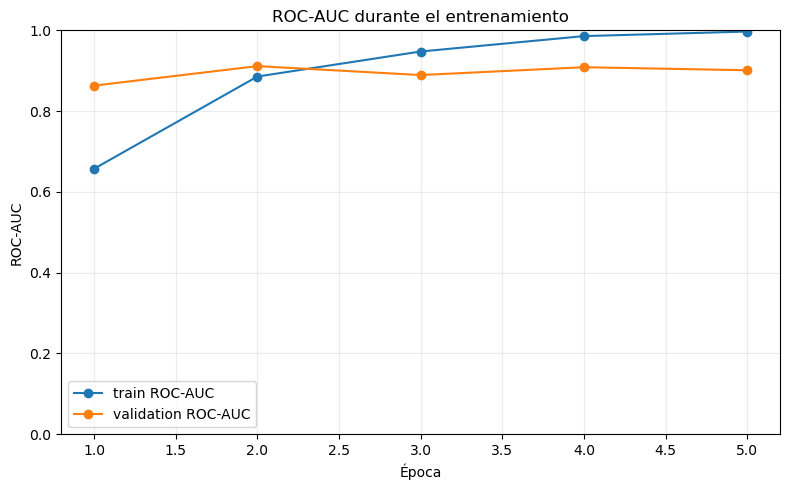

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(history_df.index, history_df["roc_auc"], marker="o", label="train ROC-AUC")
plt.plot(history_df.index, history_df["val_roc_auc"], marker="o", label="validation ROC-AUC")
plt.title("ROC-AUC durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

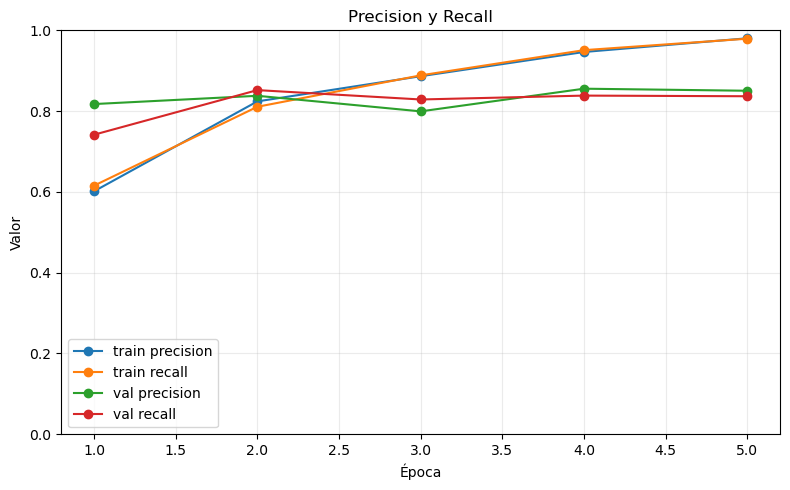

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(history_df.index, history_df["precision"], marker="o", label="train precision")
plt.plot(history_df.index, history_df["recall"], marker="o", label="train recall")
plt.plot(history_df.index, history_df["val_precision"], marker="o", label="val precision")
plt.plot(history_df.index, history_df["val_recall"], marker="o", label="val recall")
plt.title("Precision y Recall")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 15. Cargar el mejor modelo y evaluar en test

Aunque `EarlyStopping` restaura los mejores pesos, cargamos el checkpoint para dejar explícito que la evaluación se realiza con el mejor modelo guardado durante validación.

El conjunto de prueba sigue sin haberse utilizado para entrenar ni seleccionar el modelo.

In [26]:
best_model = keras.models.load_model(CHECKPOINT_PATH)

test_results = best_model.evaluate(
    test_ds,
    return_dict=True,
    verbose=1,
)

pd.Series(test_results, name="test")

196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.8364 - loss: 0.3849 - pr_auc: 0.9051 - precision: 0.8309 - recall: 0.8446 - roc_auc: 0.9086


accuracy     0.836360
loss         0.384912
pr_auc       0.905082
precision    0.830881
recall       0.844640
roc_auc      0.908560
Name: test, dtype: float64

## 16. Predicciones probabilísticas

In [27]:
y_prob = best_model.predict(test_ds, verbose=1).ravel()

# Umbral estándar para clasificación binaria.
DEFAULT_THRESHOLD = 0.50
y_pred_05 = (y_prob >= DEFAULT_THRESHOLD).astype(np.int32)

print("Probabilidades:", y_prob[:10])
print("Predicciones:  ", y_pred_05[:10])
print("Etiquetas reales:", y_test[:10])

196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step
Probabilidades: [0.09213766 0.04266845 0.12863013 0.9135682  0.9001134  0.9320281
 0.10872623 0.09183712 0.64988804 0.04729358]
Predicciones:   [0 0 0 1 1 1 0 0 1 0]
Etiquetas reales: [0 0 0 1 1 1 0 0 0 0]


## 17. Métricas completas con umbral 0.50

In [28]:
metricas_05 = {
    "Accuracy": accuracy_score(y_test, y_pred_05),
    "Precision": precision_score(y_test, y_pred_05, zero_division=0),
    "Recall": recall_score(y_test, y_pred_05, zero_division=0),
    "F1-score": f1_score(y_test, y_pred_05, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob),
    "PR-AUC / Average Precision": average_precision_score(y_test, y_prob),
}

metricas_05_df = pd.DataFrame.from_dict(
    metricas_05,
    orient="index",
    columns=["valor"],
)

metricas_05_df

,valor
Accuracy,0.836360
Precision,0.830881
Recall,0.844640
F1-score,0.837704
ROC-AUC,0.908587
PR-AUC / Average Precision,0.905175


In [29]:
print(classification_report(
    y_test,
    y_pred_05,
    target_names=["Negativa", "Positiva"],
    digits=4,
    zero_division=0,
))

              precision    recall  f1-score   support

    Negativa     0.8420    0.8281    0.8350     12500
    Positiva     0.8309    0.8446    0.8377     12500

    accuracy                         0.8364     25000
   macro avg     0.8365    0.8364    0.8363     25000
weighted avg     0.8365    0.8364    0.8363     25000



## 18. Matriz de confusión

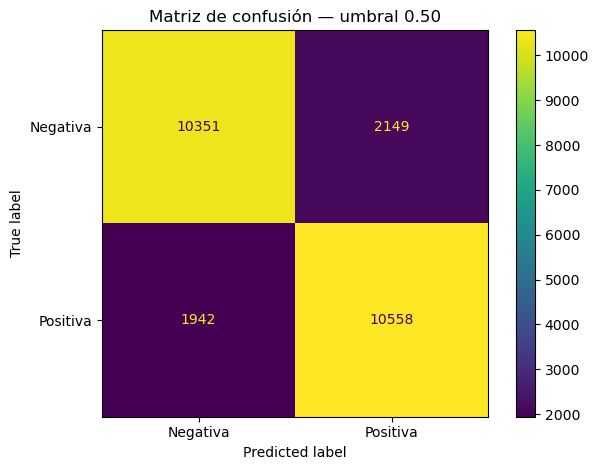

In [30]:
cm = confusion_matrix(y_test, y_pred_05)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negativa", "Positiva"],
)

disp.plot(values_format="d")
plt.title("Matriz de confusión — umbral 0.50")
plt.tight_layout()
plt.show()

## 19. Curva ROC

La curva ROC representa:

- eje X: **False Positive Rate**
- eje Y: **True Positive Rate / Recall**

El área bajo la curva, **ROC-AUC**, mide la capacidad global del modelo para ordenar ejemplos positivos por encima de negativos, independientemente de un único umbral.

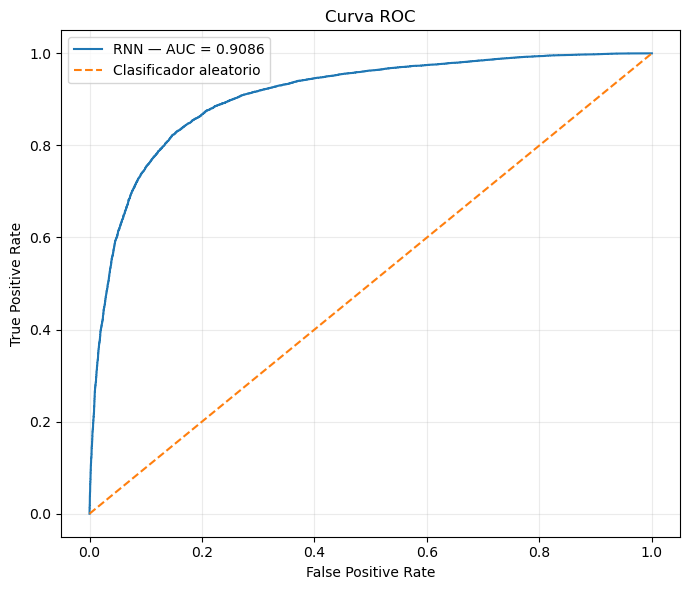

In [31]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"RNN — AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificador aleatorio")
plt.title("Curva ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 20. Curva Precision–Recall

La curva Precision–Recall es especialmente útil cuando interesa estudiar el equilibrio entre:

- **Precision:** de los ejemplos predichos como positivos, cuántos eran realmente positivos.
- **Recall:** de todos los positivos reales, cuántos detectó el modelo.

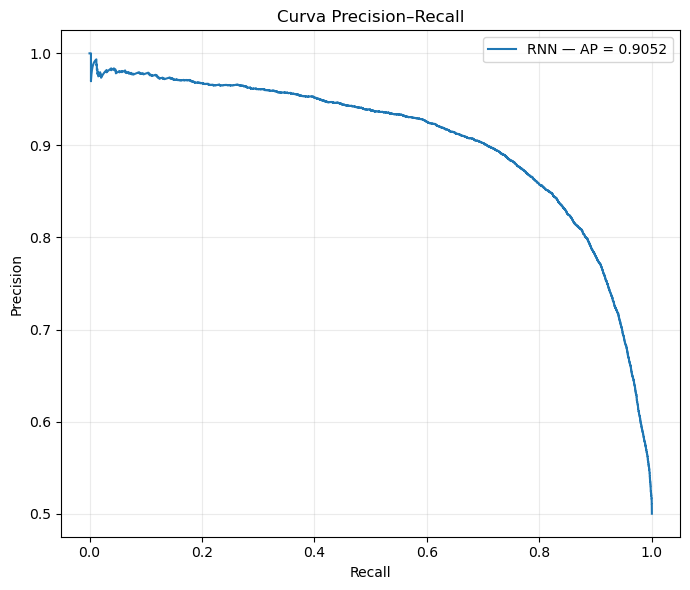

In [32]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(recall_curve, precision_curve, label=f"RNN — AP = {ap:.4f}")
plt.title("Curva Precision–Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 21. Ajuste del umbral usando **solo validación**

El valor `0.50` es estándar, pero no siempre maximiza F1.

**Buena práctica:** si queremos ajustar el umbral, debe hacerse sobre el conjunto de **validación**, nunca sobre test.

Procedimiento:

1. Obtener probabilidades en validación.
2. Calcular F1 para distintos umbrales.
3. Escoger el mejor umbral.
4. Evaluar ese umbral una única vez sobre test.

In [33]:
y_val_prob = best_model.predict(val_ds, verbose=0).ravel()

val_precision, val_recall, val_thresholds = precision_recall_curve(
    y_val,
    y_val_prob,
)

# precision y recall tienen un elemento más que thresholds.
val_f1 = (
    2 * val_precision[:-1] * val_recall[:-1]
    / (val_precision[:-1] + val_recall[:-1] + 1e-12)
)

best_idx = int(np.argmax(val_f1))
best_threshold = float(val_thresholds[best_idx])
best_val_f1 = float(val_f1[best_idx])

print(f"Mejor umbral en validación: {best_threshold:.4f}")
print(f"F1 de validación en ese umbral: {best_val_f1:.4f}")

Mejor umbral en validación: 0.4355
F1 de validación en ese umbral: 0.8465


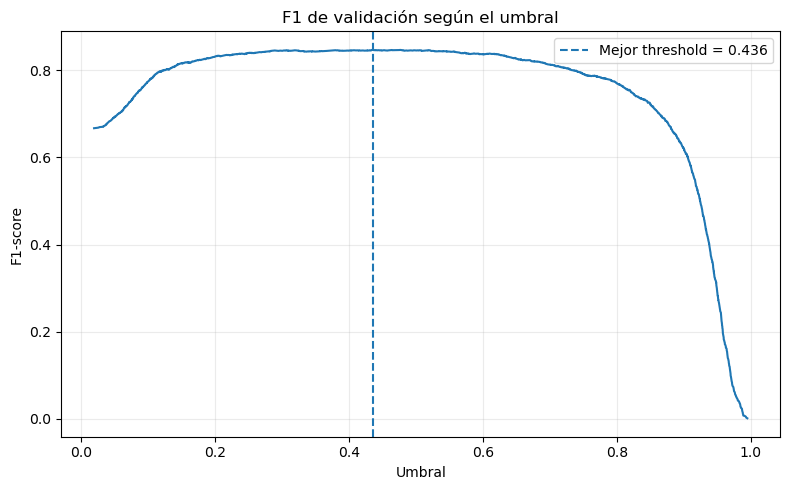

In [34]:
plt.figure(figsize=(8, 5))
plt.plot(val_thresholds, val_f1)
plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Mejor threshold = {best_threshold:.3f}",
)
plt.title("F1 de validación según el umbral")
plt.xlabel("Umbral")
plt.ylabel("F1-score")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### 21.1 Evaluación en test con el umbral seleccionado en validación

In [35]:
y_pred_opt = (y_prob >= best_threshold).astype(np.int32)

metricas_opt = {
    "Accuracy": accuracy_score(y_test, y_pred_opt),
    "Precision": precision_score(y_test, y_pred_opt, zero_division=0),
    "Recall": recall_score(y_test, y_pred_opt, zero_division=0),
    "F1-score": f1_score(y_test, y_pred_opt, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob),
    "PR-AUC / Average Precision": average_precision_score(y_test, y_prob),
}

comparacion = pd.DataFrame(
    {
        "threshold_0.50": metricas_05,
        f"threshold_{best_threshold:.3f}": metricas_opt,
    }
)

comparacion

,threshold_0.50,threshold_0.436
Accuracy,0.836360,0.833920
Precision,0.830881,0.817318
Recall,0.844640,0.860080
F1-score,0.837704,0.838154
ROC-AUC,0.908587,0.908587
PR-AUC / Average Precision,0.905175,0.905175


## 22. Matriz de confusión con el umbral optimizado

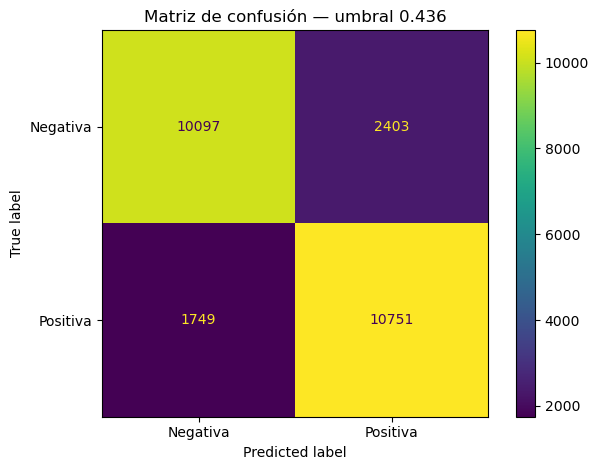

In [36]:
cm_opt = confusion_matrix(y_test, y_pred_opt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_opt,
    display_labels=["Negativa", "Positiva"],
)

disp.plot(values_format="d")
plt.title(f"Matriz de confusión — umbral {best_threshold:.3f}")
plt.tight_layout()
plt.show()

## 23. Análisis de errores

Observar ejemplos mal clasificados permite identificar limitaciones del modelo.

Aquí se muestran falsos positivos y falsos negativos junto con la probabilidad estimada.

In [37]:
false_positive_idx = np.where((y_test == 0) & (y_pred_opt == 1))[0]
false_negative_idx = np.where((y_test == 1) & (y_pred_opt == 0))[0]

print("Falsos positivos:", len(false_positive_idx))
print("Falsos negativos:", len(false_negative_idx))

Falsos positivos: 2403
Falsos negativos: 1749


In [38]:
def tabla_errores(indices, tipo, n=5):
    registros = []

    for idx in indices[:n]:
        texto = decodificar_reseña(x_test_raw[idx])

        registros.append(
            {
                "indice_test": int(idx),
                "tipo": tipo,
                "real": int(y_test[idx]),
                "prob_positiva": float(y_prob[idx]),
                "texto": texto[:700],
            }
        )

    return pd.DataFrame(registros)


errores_fp = tabla_errores(false_positive_idx, "Falso positivo", n=5)
errores_fn = tabla_errores(false_negative_idx, "Falso negativo", n=5)

pd.concat([errores_fp, errores_fn], ignore_index=True)

,indice_test,tipo,real,prob_positiva,texto
0,8,Falso positivo,0,0.649888,a more detailed review can be obtained anywher...
1,32,Falso positivo,0,0.607210,critics are falling over themselves within the...
2,50,Falso positivo,0,0.573782,stupid horror film about five 20 somethings 3 ...
3,53,Falso positivo,0,0.702451,in my opinion of this movie the entire video p...
4,65,Falso positivo,0,0.910359,although allegedly autobiographical this movie...
5,24,Falso negativo,1,0.064739,1969 was the year new york city was the place ...
6,25,Falso negativo,1,0.052256,i think this show is awesome i love it and i l...
7,27,Falso negativo,1,0.088302,can this really be a troma movie some scenes a...
8,28,Falso negativo,1,0.152121,okay this may not be the most sophisticated mo...
9,30,Falso negativo,1,0.240338,dr [OOV] philippe [OOV] a wealthy physician wi...


## 24. Guardar el modelo final y la configuración

Se guarda:

- el modelo completo en formato `.keras`;
- un archivo JSON con los parámetros necesarios para reproducir el preprocesamiento.

In [39]:
best_model.save(FINAL_MODEL_PATH)

config = {
    "dataset": "IMDB Large Movie Review Dataset - Keras",
    "num_words": NUM_WORDS,
    "maxlen": MAXLEN,
    "embedding_dim": EMBEDDING_DIM,
    "rnn_units": RNN_UNITS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "seed": SEED,
    "train_examples": int(len(x_train)),
    "validation_examples": int(len(x_val)),
    "test_examples": int(len(x_test)),
    "selected_threshold": best_threshold,
}

with open("config_rnn_imdb.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=4, ensure_ascii=False)

print("Modelo:", FINAL_MODEL_PATH.resolve())
print("Configuración:", Path("config_rnn_imdb.json").resolve())

Modelo: C:\Users\josia\sexto_semestre\inteligencia_artificial_II\laboratorios\laboratorio03\rnn_imdb_final.keras
Configuración: C:\Users\josia\sexto_semestre\inteligencia_artificial_II\laboratorios\laboratorio03\config_rnn_imdb.json


## 25. Función de inferencia sobre una secuencia del dataset

La siguiente función recibe una reseña **ya codificada con los índices de IMDB** y devuelve su probabilidad de sentimiento positivo.

> Para texto nuevo escrito por un usuario sería conveniente implementar exactamente el mismo tokenizador que se utilizó al crear el dataset. El `word_index` por sí solo permite una aproximación, pero no reproduce necesariamente todo el preprocesamiento original.

In [40]:
def predecir_secuencia_imdb(sequence, threshold=best_threshold):
    sequence_pad = preparar_secuencias([sequence])

    prob = float(best_model.predict(sequence_pad, verbose=0)[0, 0])
    pred = int(prob >= threshold)

    return {
        "probabilidad_positiva": prob,
        "prediccion": pred,
        "sentimiento": "positivo" if pred == 1 else "negativo",
        "threshold": float(threshold),
    }


ejemplo = 10

print("Texto:")
print(decodificar_reseña(x_test_raw[ejemplo])[:1200])
print()
print("Real:", "positivo" if y_test[ejemplo] == 1 else "negativo")
print("Modelo:", predecir_secuencia_imdb(x_test_raw[ejemplo]))

Texto:
critics claim that this film is one of the worst films ever watchers also claim the same but there is a flip side to that coin they are wrong very wrong it's the most clever film i've seen in ages br br from beginning till end you see a story thats unrealistic a story that [OOV] the real world this film is like a mirror you see yourself in another way that people see you to really understand the directors point of view you have to see it another time br br when you see this film try to understand the story and watch the background listen to the lyrics of the music and smell the industrial [OOV] br br this film is one of a kind you'll hate it most people do or you'll love it and understand it completely br br ernest [OOV] once said 'the world is a fine place and worth fighting [OOV] i agree with the second part

Real: positivo
Modelo: {'probabilidad_positiva': 0.8814154863357544, 'prediccion': 1, 'sentimiento': 'positivo', 'threshold': 0.43552690744400024}


## 26. Interpretación de resultados

Al terminar el entrenamiento, analiza principalmente:

### 1. Generalización

Compara:

- `train_loss` vs `val_loss`
- `train_accuracy` vs `val_accuracy`

Si entrenamiento mejora mucho mientras validación empeora, aparece **overfitting**.

### 2. Accuracy

Es útil aquí porque IMDB está aproximadamente balanceado entre clases.

### 3. Precision y Recall

- Precision alta → pocas reseñas negativas se clasifican erróneamente como positivas.
- Recall alto → el modelo detecta una gran proporción de las reseñas positivas.

### 4. F1-score

Resume el equilibrio entre Precision y Recall.

\[
F_1 = 2\frac{Precision \cdot Recall}{Precision + Recall}
\]

### 5. ROC-AUC y PR-AUC

Evalúan las probabilidades del modelo sin depender únicamente del umbral 0.50.

### 6. Matriz de confusión

Permite ver exactamente:

- verdaderos negativos;
- falsos positivos;
- falsos negativos;
- verdaderos positivos.

### 7. Análisis de errores

Lee algunos errores. Las reseñas con ironía, negaciones complejas, opiniones mixtas o dependencias muy largas suelen ser especialmente difíciles para una `SimpleRNN`.

## 27. Limitaciones de una `SimpleRNN`

Una RNN clásica puede sufrir:

- **vanishing gradients**;
- dificultad para mantener dependencias de largo alcance;
- entrenamiento secuencial relativamente lento.

Por eso, una continuación natural de esta práctica es mantener **exactamente el mismo preprocesamiento y particiones** y comparar:

1. `SimpleRNN`
2. `GRU`
3. `LSTM`
4. `Bidirectional(LSTM)` o `Bidirectional(GRU)`

Así la comparación será metodológicamente justa.

### Cambio mínimo para probar una GRU

```python
x = layers.GRU(64)(x)
```

### Cambio mínimo para probar una LSTM

```python
x = layers.LSTM(64)(x)
```

No cambies simultáneamente muchas otras variables si tu objetivo es medir qué arquitectura recurrente funciona mejor.

## 28. Checklist de buenas prácticas aplicadas

- [x] Más de 20.000 ejemplos reales de entrenamiento.
- [x] Secuencias con `n = 300 > 20`.
- [x] Test oficial separado y sin utilizar para elegir hiperparámetros.
- [x] Validación estratificada.
- [x] Semillas para reproducibilidad.
- [x] Padding consistente.
- [x] `Embedding` con máscara de padding.
- [x] Pipeline con `tf.data`.
- [x] Regularización.
- [x] Gradient clipping.
- [x] `EarlyStopping`.
- [x] Reducción de learning rate.
- [x] Checkpoint del mejor modelo.
- [x] Accuracy, Precision, Recall, F1, ROC-AUC y PR-AUC.
- [x] Matriz de confusión.
- [x] Curva ROC.
- [x] Curva Precision–Recall.
- [x] Ajuste de threshold solamente con validación.
- [x] Análisis de ejemplos mal clasificados.
- [x] Guardado del modelo y configuración.